<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/City_Lifestyle_Segmentation_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# City Lifestyle Segmentation Dataset

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# About the Dataset


The City Lifestyle Segmentation Dataset comprises 300 unique city entries across 10 features, with no missing values or duplicate records, indicating a clean and complete dataset. The dataset includes two categorical features: city_name, which is unique for each entry, and country, represented by 6 distinct continents, with Asia having the highest representation (80 cities). The remaining eight features are numerical, detailing various aspects of city life: population_density (ranging from 100 to 14427), avg_income (480 to 5720), internet_penetration (34% to 100%), avg_rent (170 to 2430), air_quality_index (22 to 146), public_transport_score (15 to 95), happiness_score (2.5 to 8.5), and green_space_ratio (2% to 58%).

Key insights from the EDA include:

Income and Rent Relationship: There's a notable positive correlation between avg_income and avg_rent, suggesting that cities with higher average incomes tend to have higher average rents.
Density and Quality of Life: Higher population_density shows a positive correlation with air_quality_index (indicating worse air quality in denser cities) and public_transport_score (suggesting denser cities have more developed public transport systems). Conversely, population_density tends to have a negative correlation with green_space_ratio, implying that more densely populated areas often have less green space.
Happiness Factors: The happiness_score appears to be positively correlated with green_space_ratio and internet_penetration, while showing a negative correlation with air_quality_index. This suggests that access to green spaces, good internet connectivity, and better air quality might contribute to higher perceived happiness in cities.
Continental Differences: The box plots revealed variations in certain metrics across continents. For instance, some continents might exhibit generally higher average incomes or population densities compared to others, influencing other lifestyle factors.

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d umuttuygurr/city-lifestyle-segmentation-dataset

# Unziping the downloaded file
!unzip city-lifestyle-segmentation-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/umuttuygurr/city-lifestyle-segmentation-dataset
License(s): CC0-1.0
  0% 0.00/11.0k [00:00<?, ?B/s]
100% 11.0k/11.0k [00:00<00:00, 38.7MB/s]
Archive:  city-lifestyle-segmentation-dataset.zip
  inflating: city_lifestyle_dataset.csv  
  inflating: kaggle_readme.md        


In [3]:
df = pd.read_csv('city_lifestyle_dataset.csv')
df.head(11)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
5,North Falls,Europe,1444,4640,78.5,1620,35,51.6,8.4,20.3
6,Hillhaven,Europe,1233,3450,84.2,1080,55,47.5,8.5,50.0
7,Gardenton,Europe,936,3610,72.4,1520,47,59.5,7.9,35.6
8,Springsville,Europe,2938,5220,100.0,1950,53,60.0,8.5,34.8
9,North Ridge,Europe,3513,3330,88.7,1040,76,60.1,7.7,31.7


In [4]:
df.tail(11)

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
289,Beachdale,Oceania,1734,3700,96.4,1090,35,54.7,8.5,28.0
290,New Forest,Oceania,1255,2890,86.4,940,28,53.4,8.5,35.2
291,Fallsland,Oceania,1107,4600,89.1,1300,50,67.7,8.5,39.9
292,Ridgeland,Oceania,1743,3500,78.0,1260,36,44.3,8.3,23.3
293,Port Forest,Oceania,353,2500,80.2,840,40,29.9,7.6,36.1
294,West Falls,Oceania,761,3180,68.4,1220,45,48.2,8.5,46.8
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [5]:
df.shape

(300, 10)

In [6]:
df.columns

Index(['city_name', 'country', 'population_density', 'avg_income',
       'internet_penetration', 'avg_rent', 'air_quality_index',
       'public_transport_score', 'happiness_score', 'green_space_ratio'],
      dtype='object')

In [7]:
df.dtypes

,0
city_name,object
country,object
population_density,int64
avg_income,int64
internet_penetration,float64
avg_rent,int64
air_quality_index,int64
public_transport_score,float64
happiness_score,float64
green_space_ratio,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city_name,300,300,Townshire,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,300,6,Asia,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_density,300.0,NaN,NaN,NaN,3944.843333,2982.566777,100.0,1830.0,3083.5,4823.75,14427.0
avg_income,300.0,NaN,NaN,NaN,2827.2,1201.163939,480.0,1907.5,2810.0,3752.5,5720.0
internet_penetration,300.0,NaN,NaN,NaN,74.305333,17.014492,34.0,64.4,75.0,87.225,100.0
avg_rent,300.0,NaN,NaN,NaN,1002.766667,456.282066,170.0,640.0,990.0,1332.5,2430.0
air_quality_index,300.0,NaN,NaN,NaN,71.246667,25.344961,22.0,54.0,67.5,86.0,146.0
public_transport_score,300.0,NaN,NaN,NaN,55.717333,14.712549,15.0,46.075,54.7,64.2,95.0
happiness_score,300.0,NaN,NaN,NaN,6.644,1.685864,2.5,5.3,6.9,8.5,8.5
green_space_ratio,300.0,NaN,NaN,NaN,33.993333,9.434067,2.0,28.225,34.7,40.4,58.0


In [10]:
df.isnull().sum()

,0
city_name,0
country,0
population_density,0
avg_income,0
internet_penetration,0
avg_rent,0
air_quality_index,0
public_transport_score,0
happiness_score,0
green_space_ratio,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

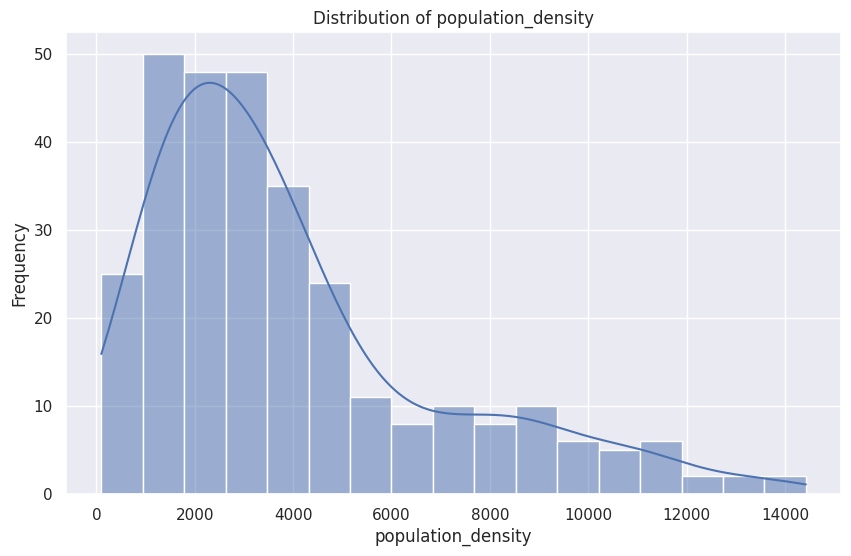

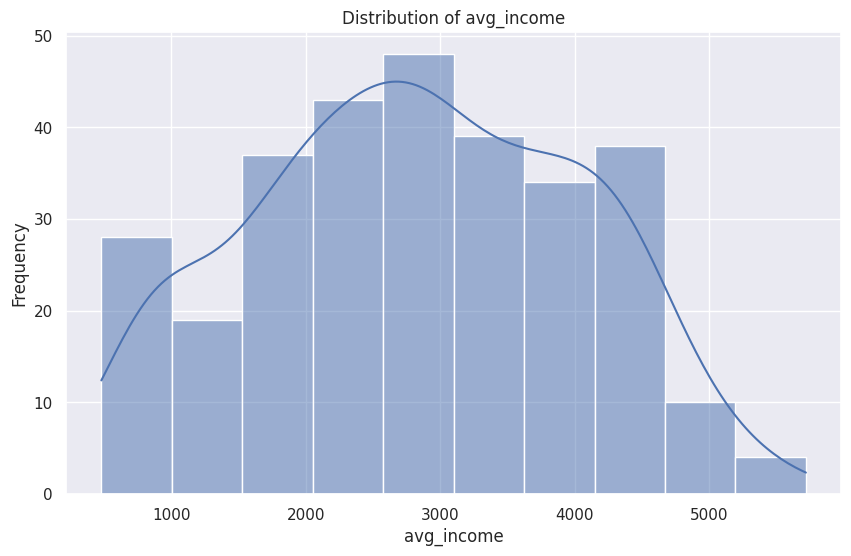

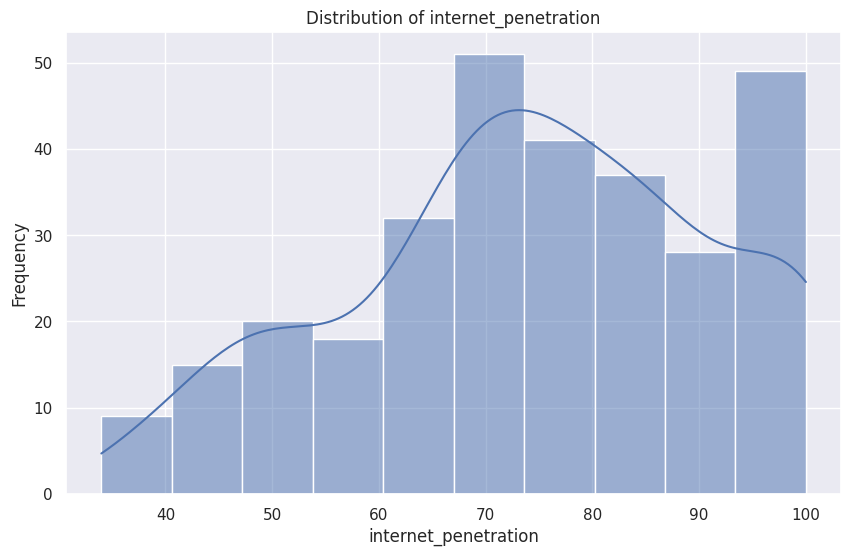

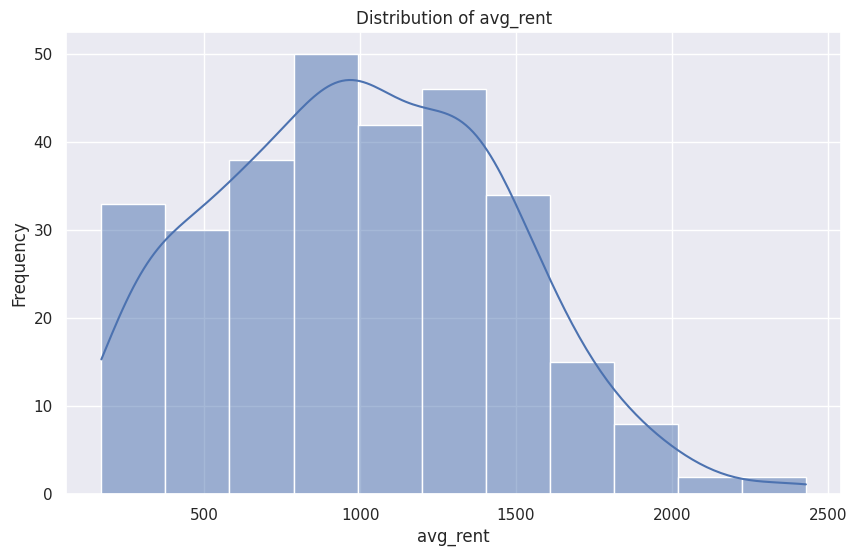

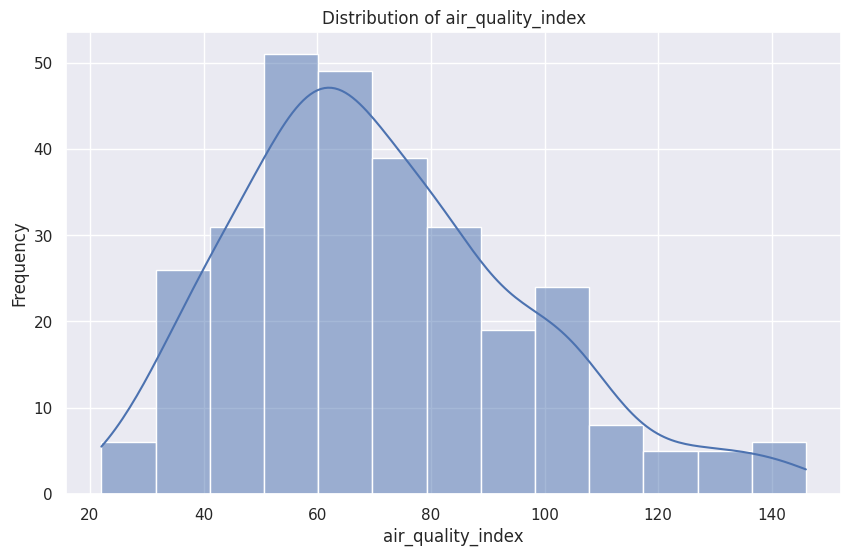

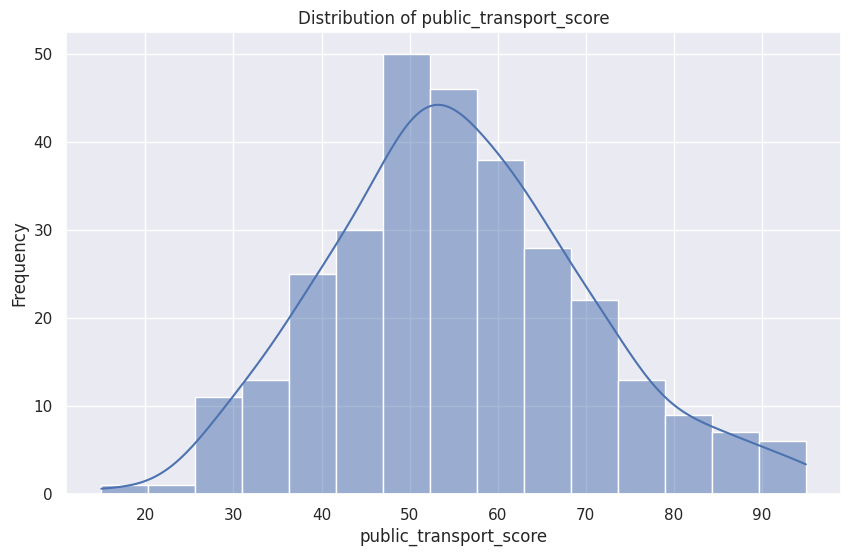

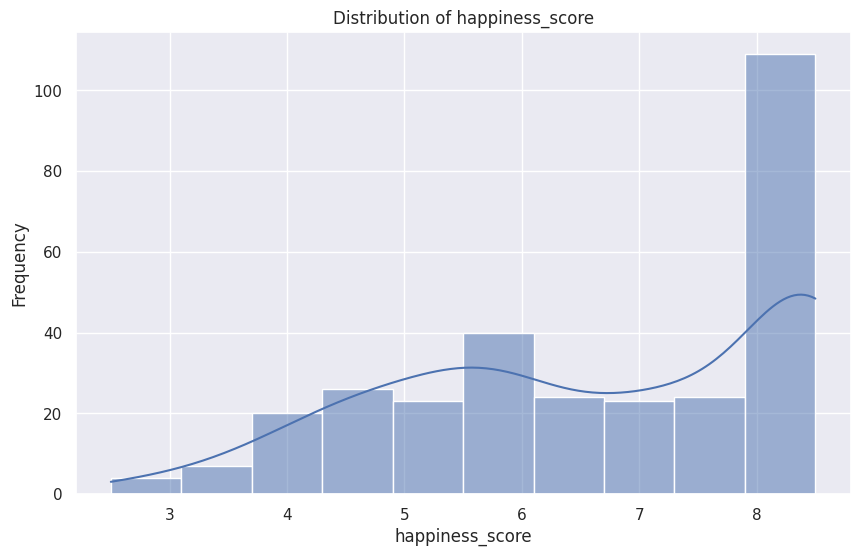

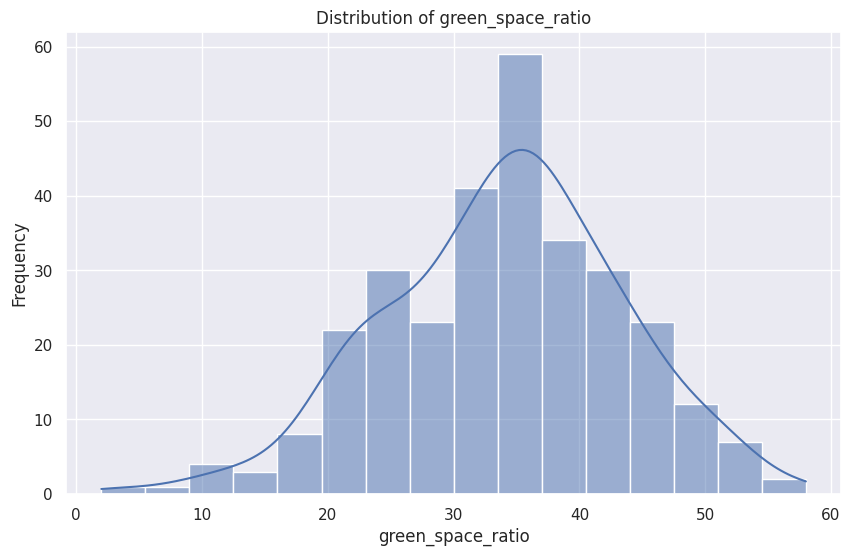

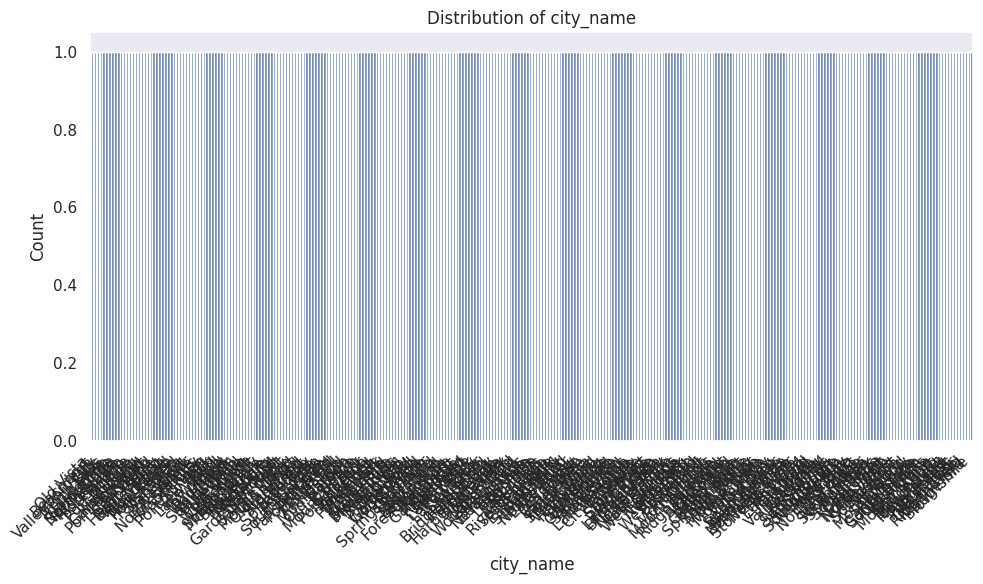

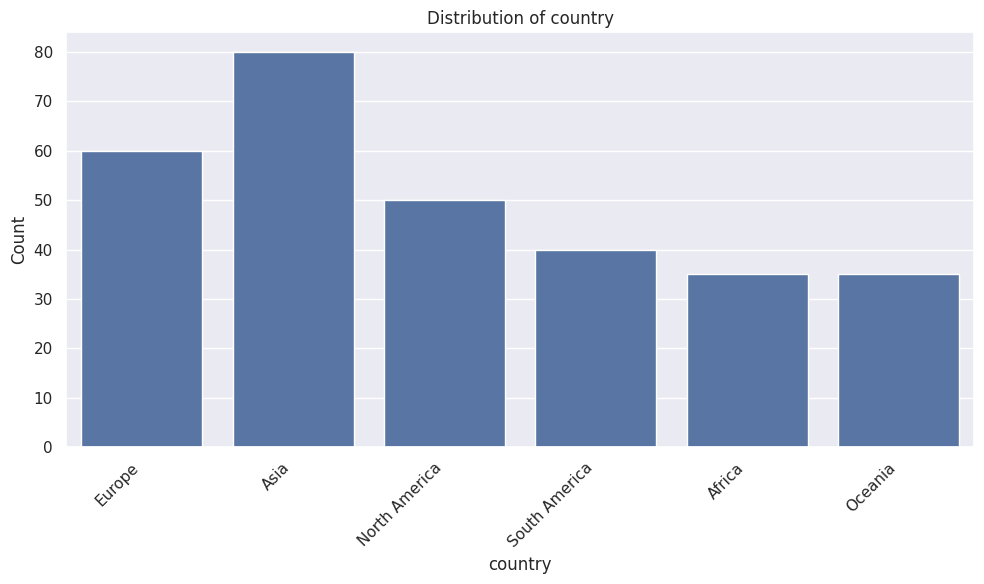

Value counts for city_name:
city_name
Townshire        1
Old Vista        1
Beachport        1
Valleyborough    1
City             1
                ..
Riverburg        1
Stone            1
Port Bridge      1
Bridge           1
Garden           1
Name: count, Length: 300, dtype: int64

Value counts for country:
country
Asia             80
Europe           60
North America    50
South America    40
Africa           35
Oceania          35
Name: count, dtype: int64



In [17]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

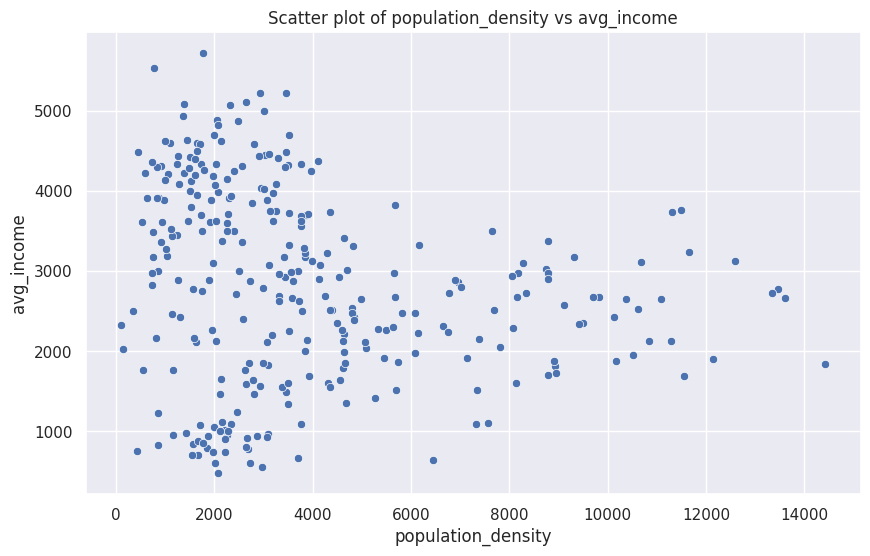

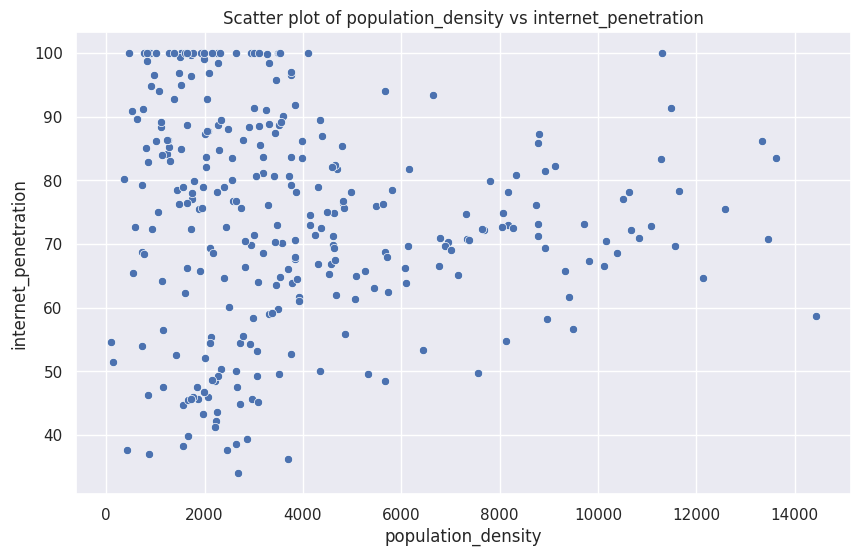

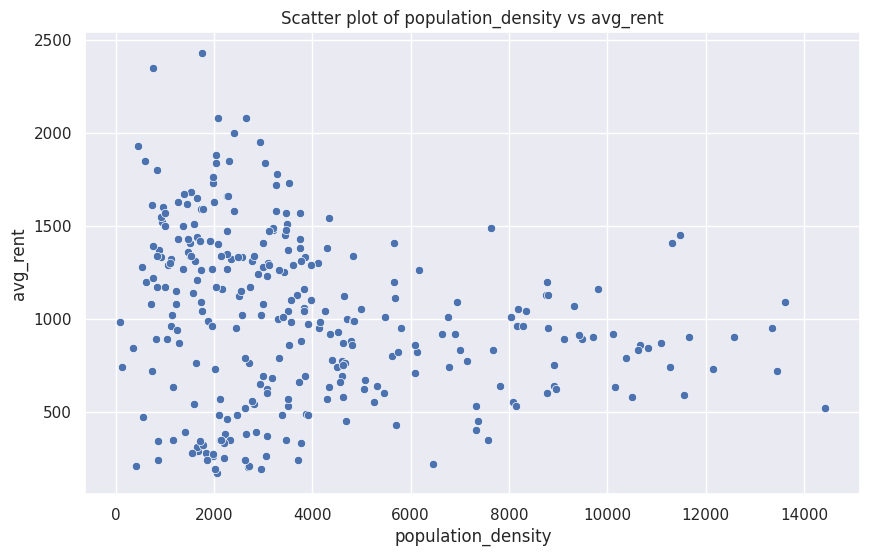

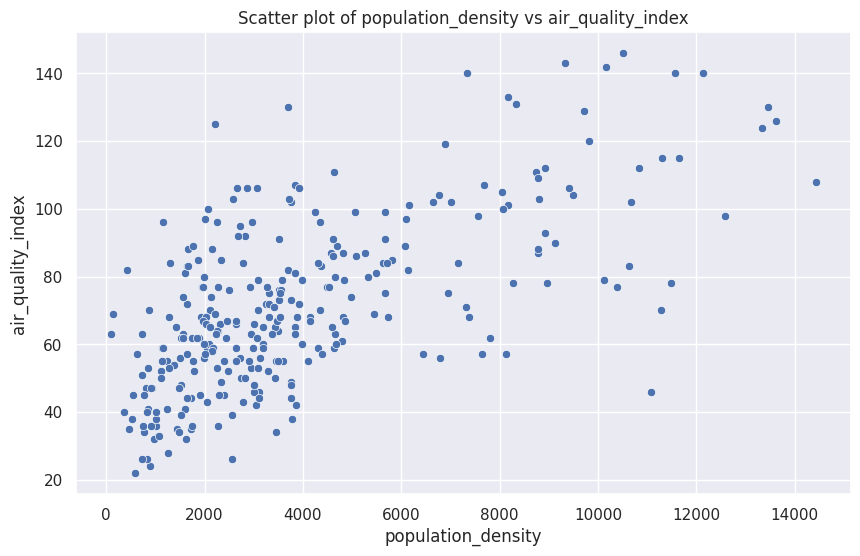

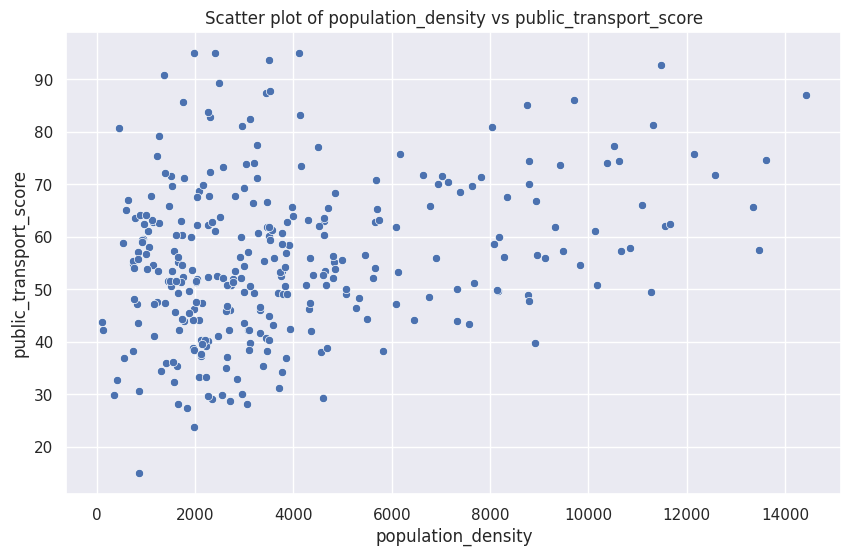

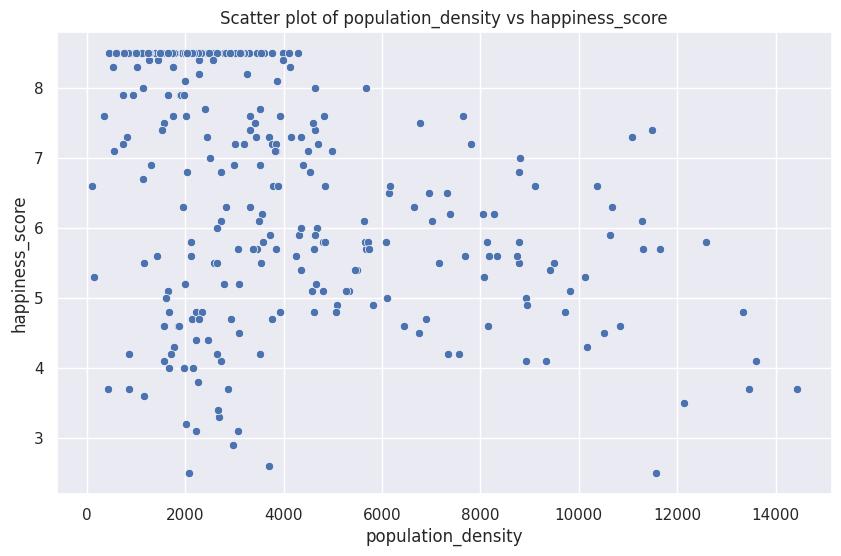

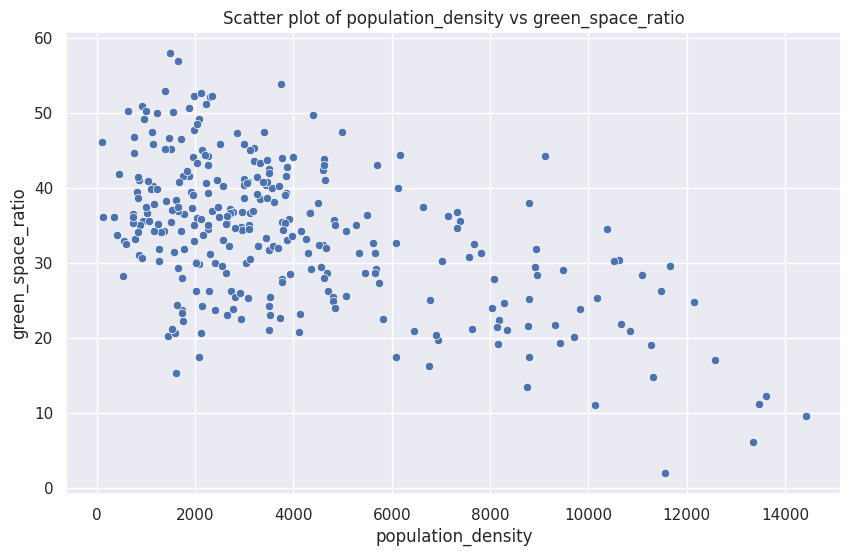

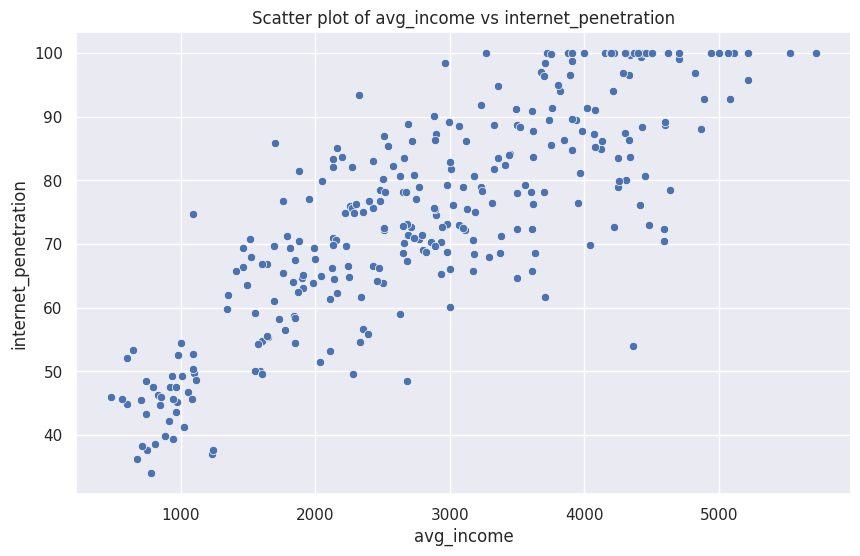

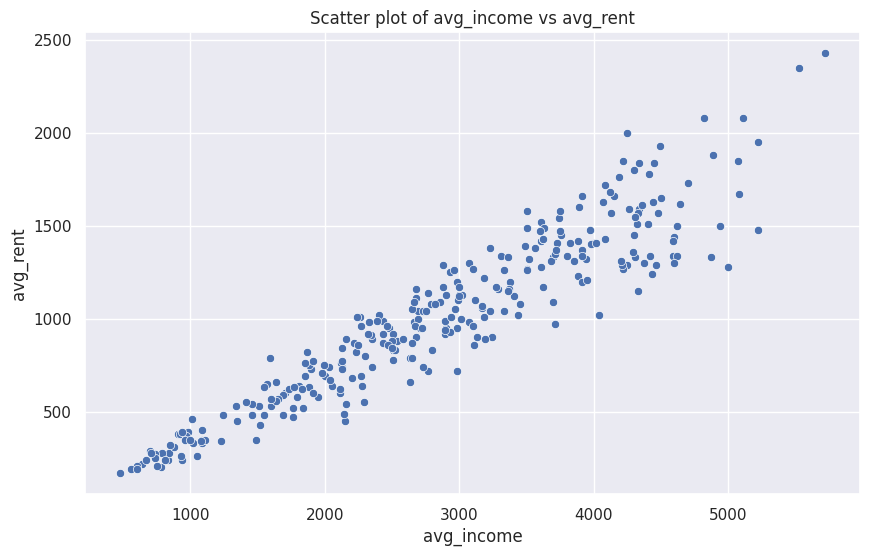

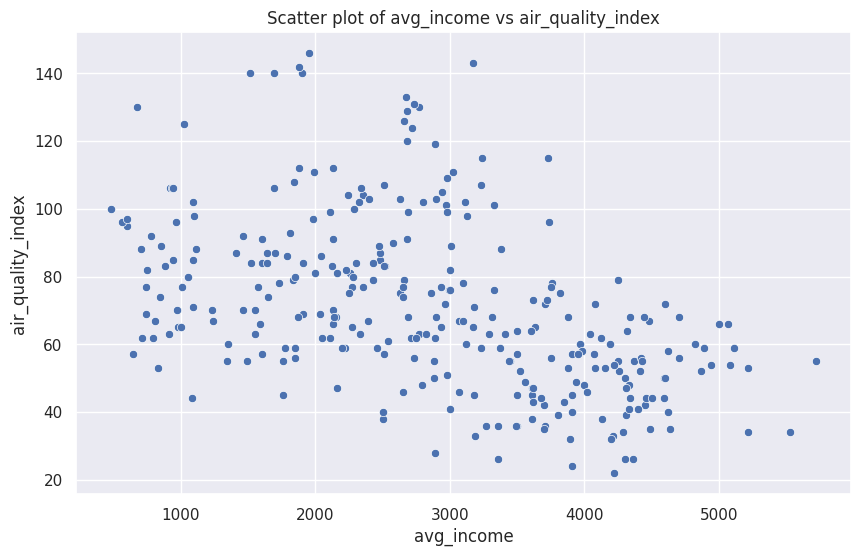

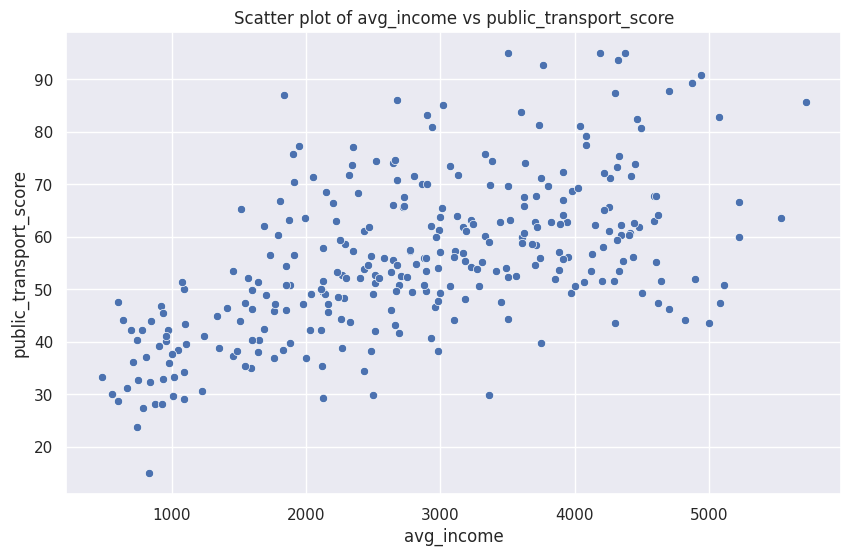

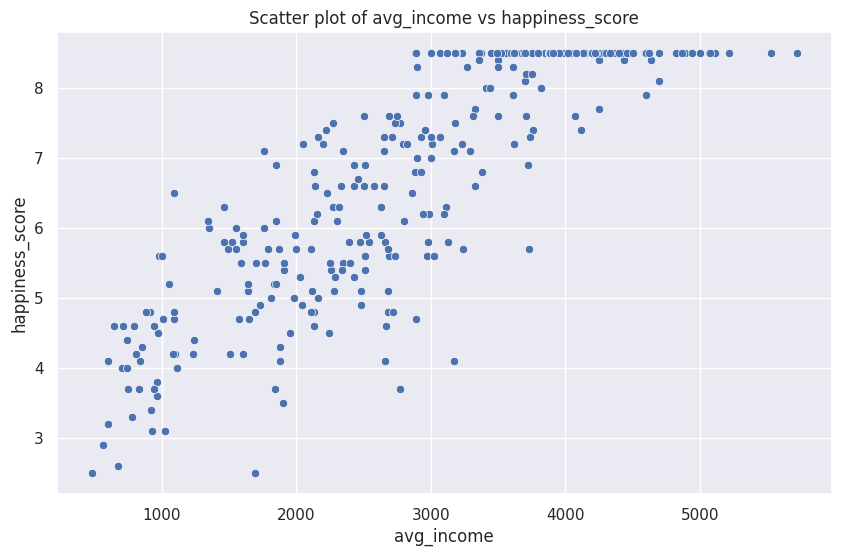

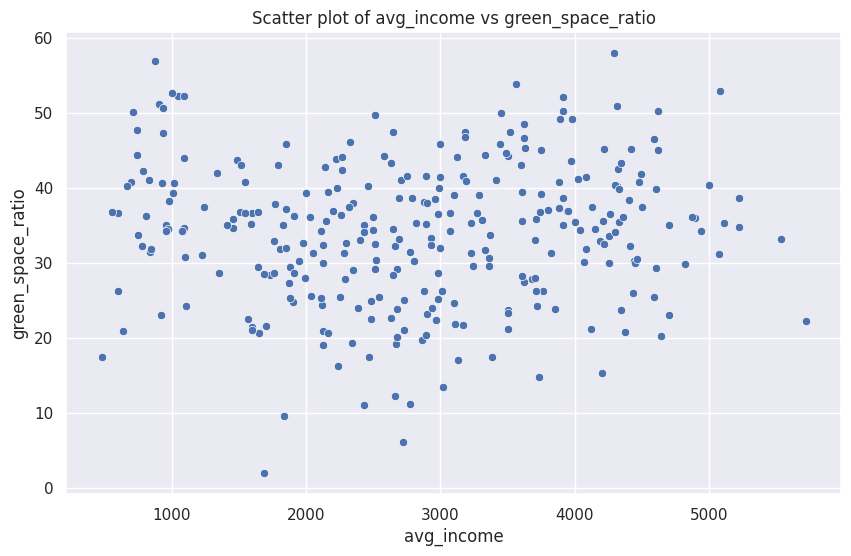

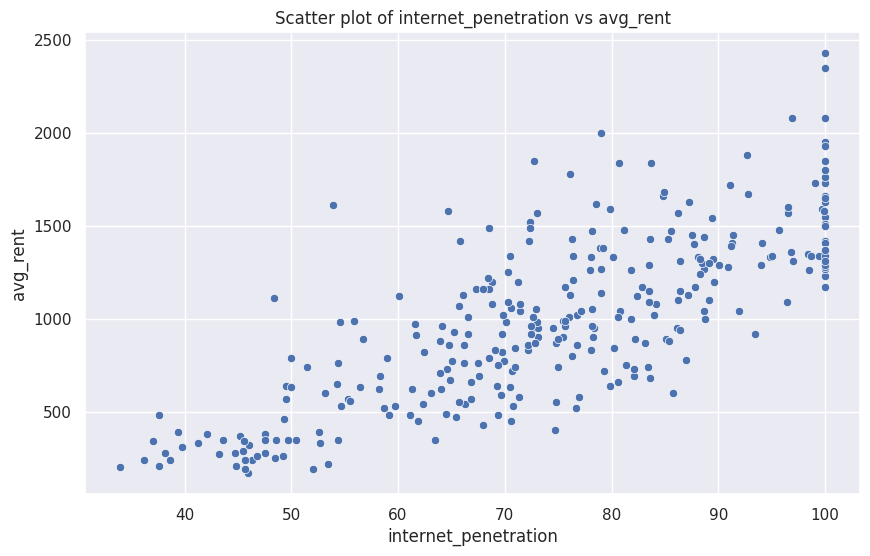

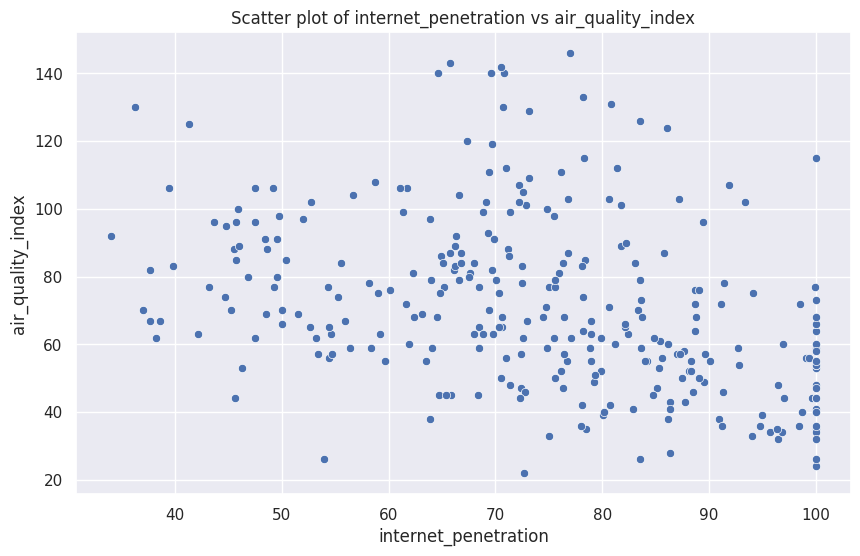

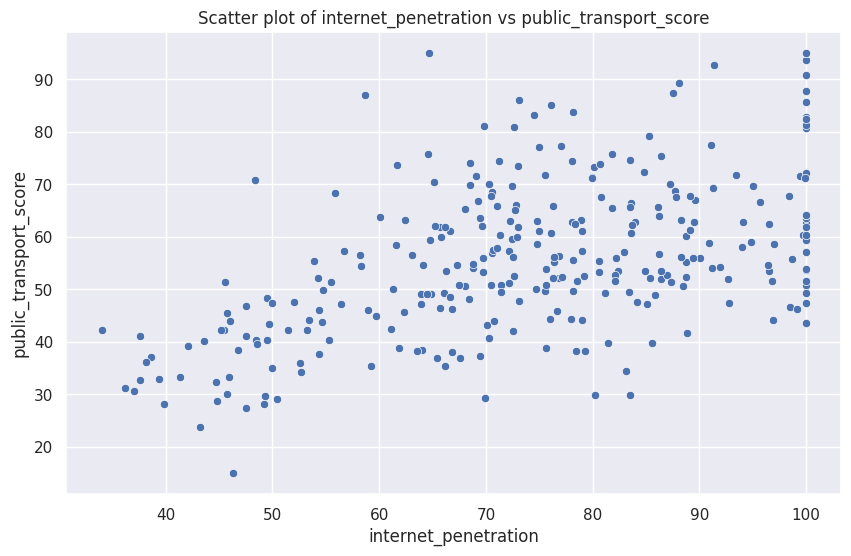

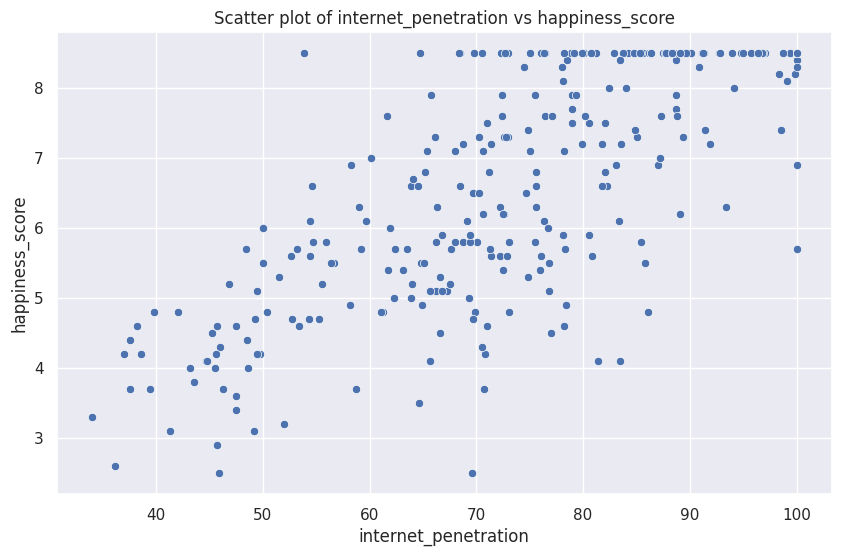

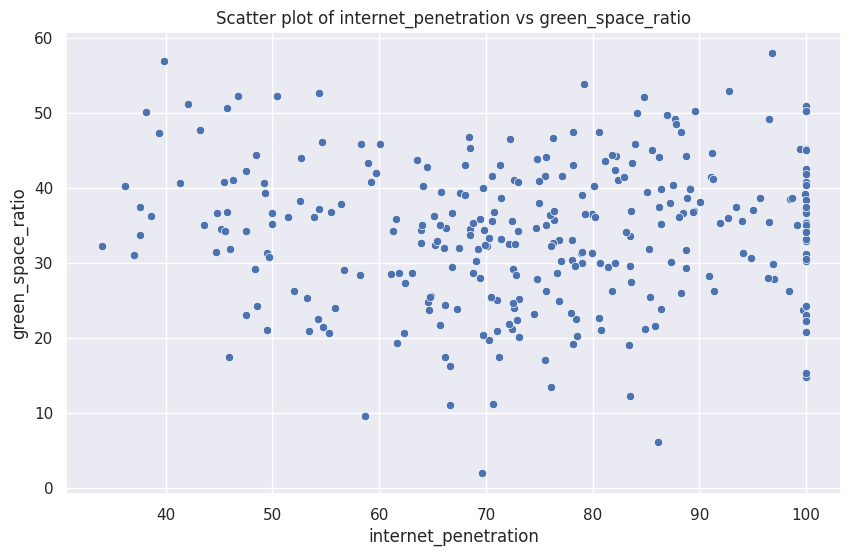

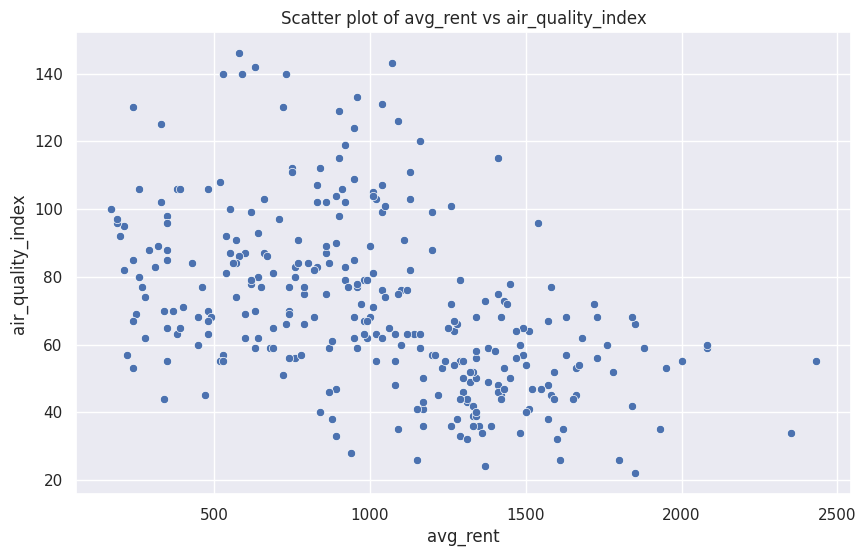

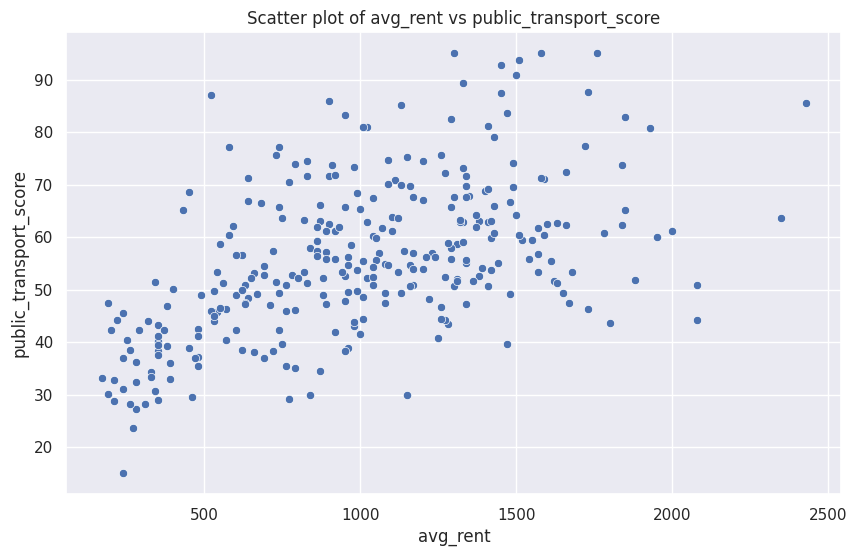

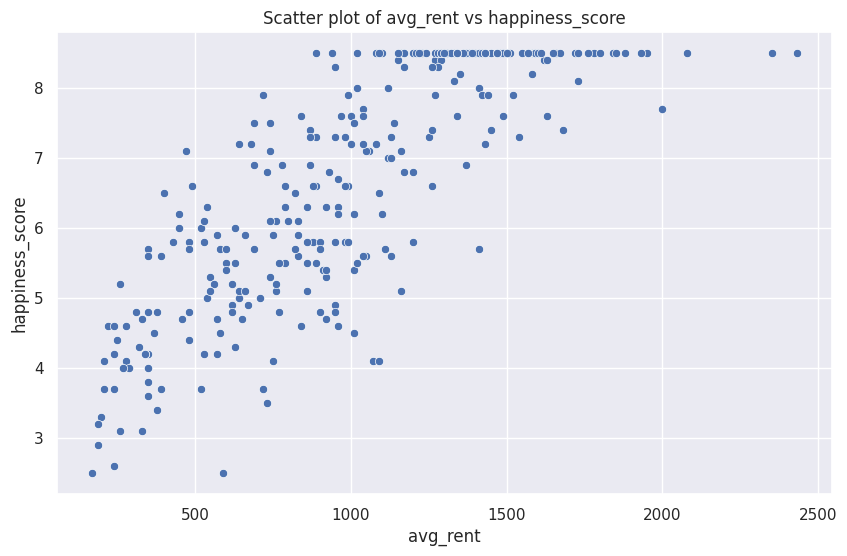

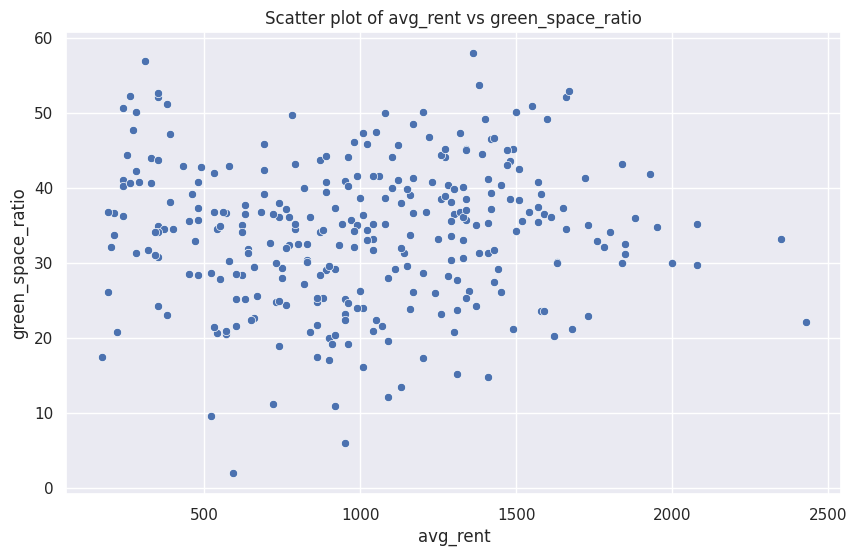

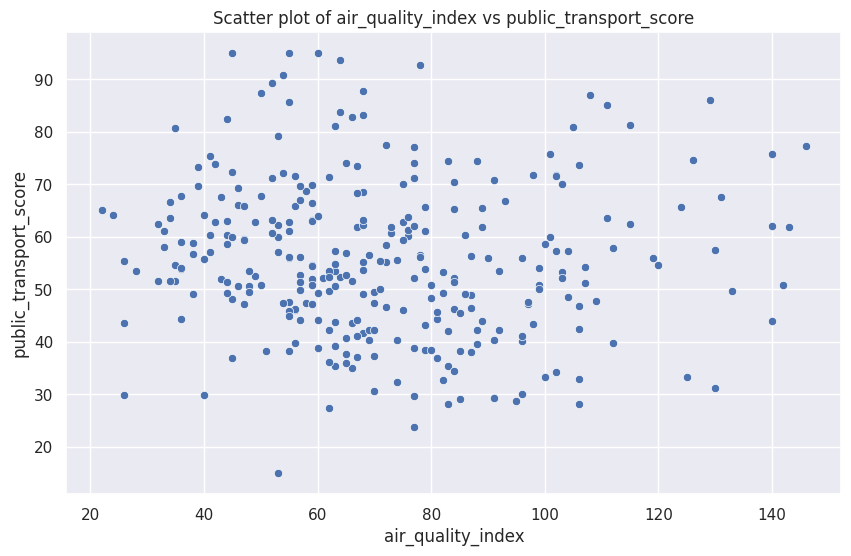

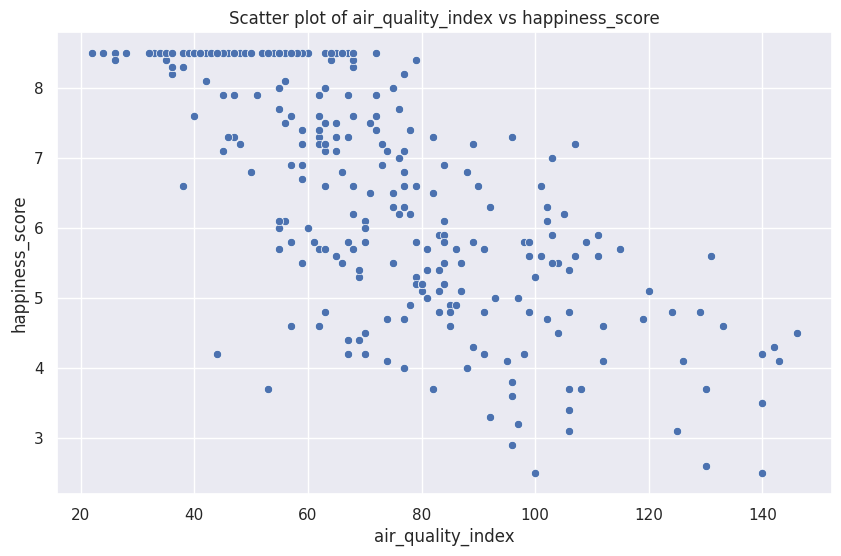

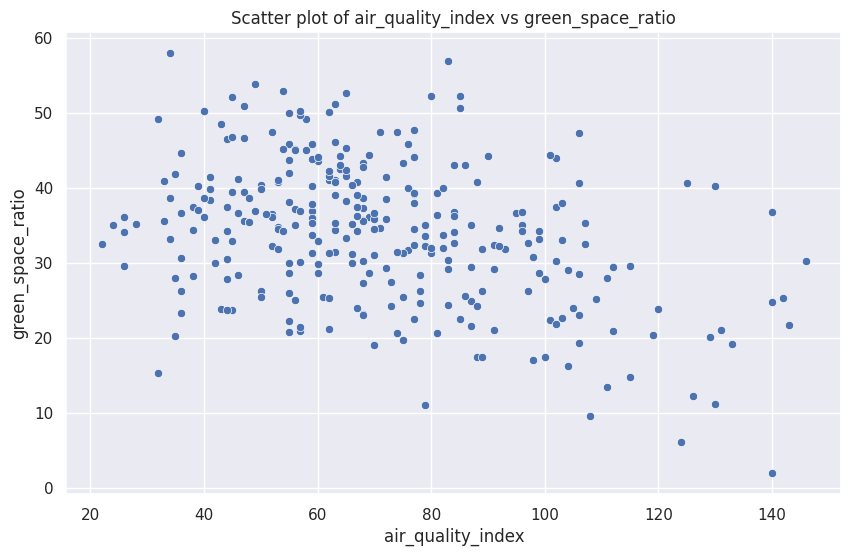

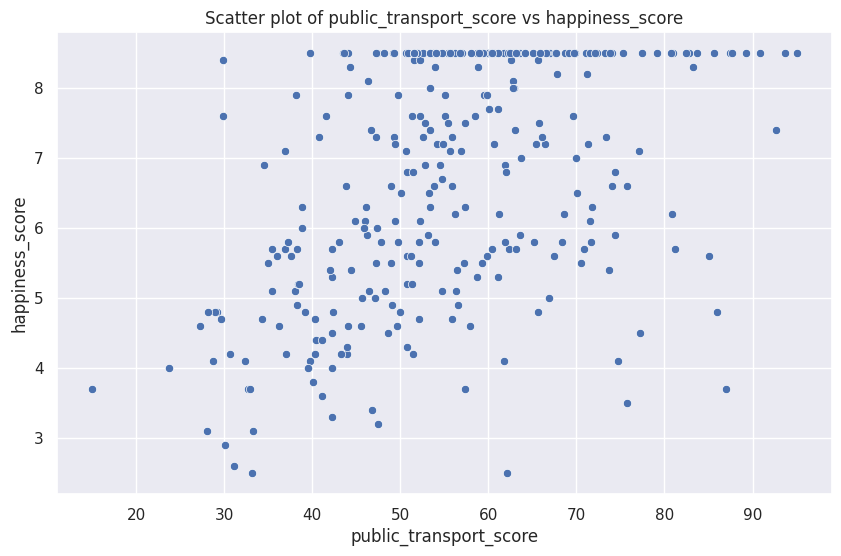

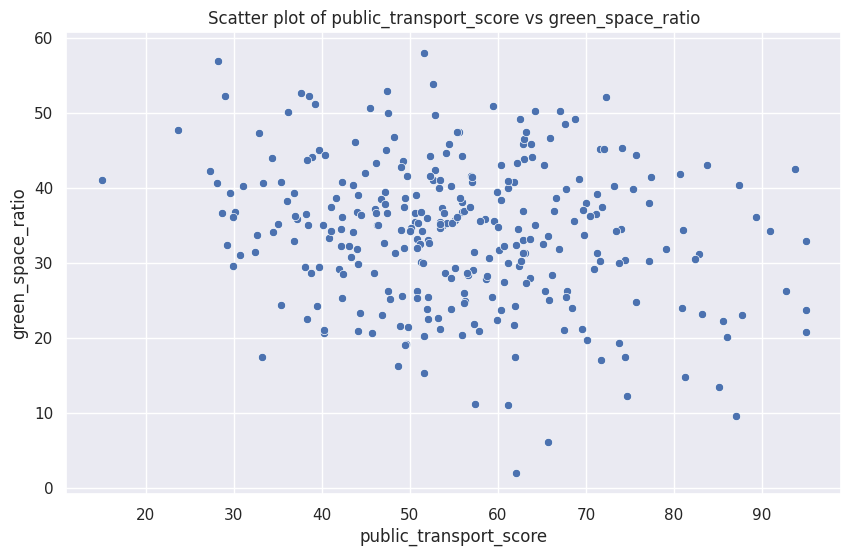

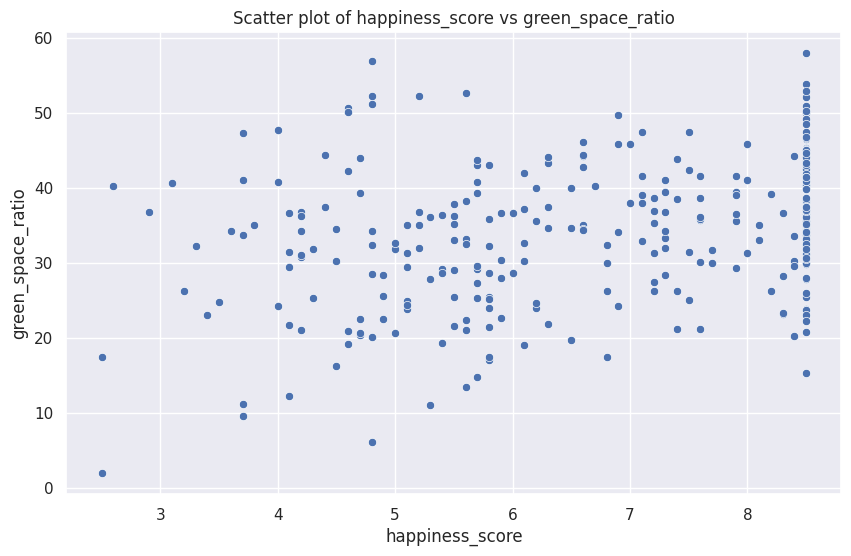

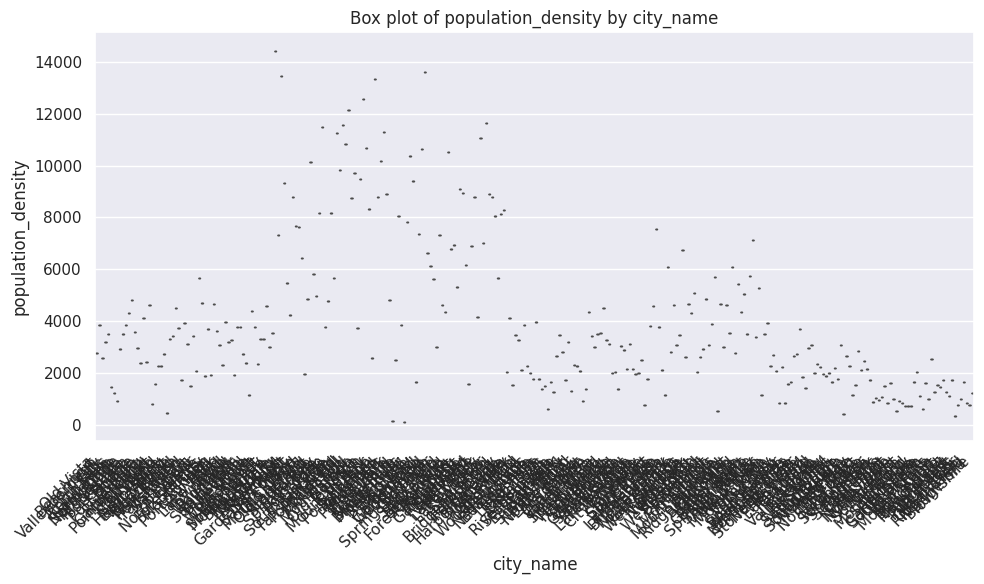

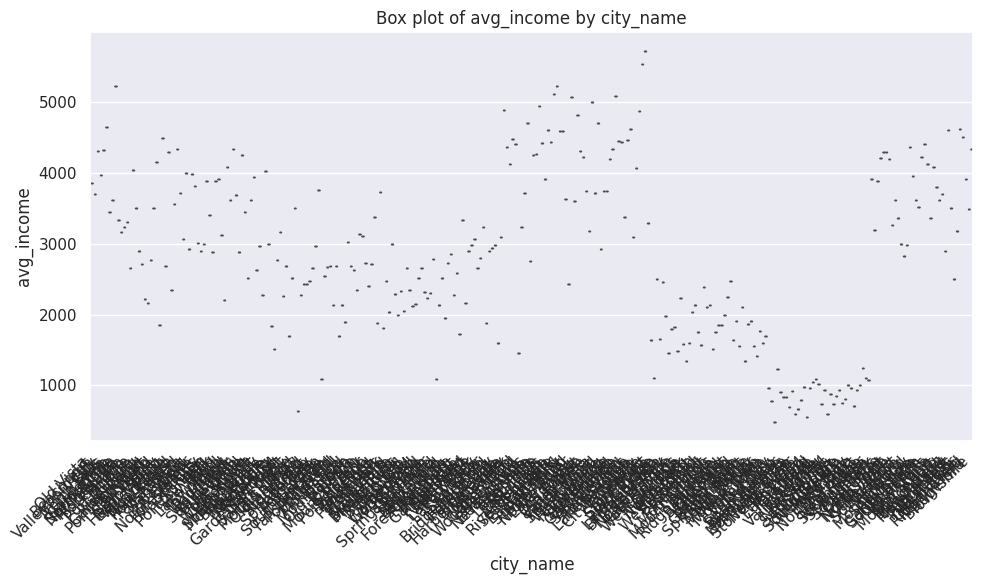

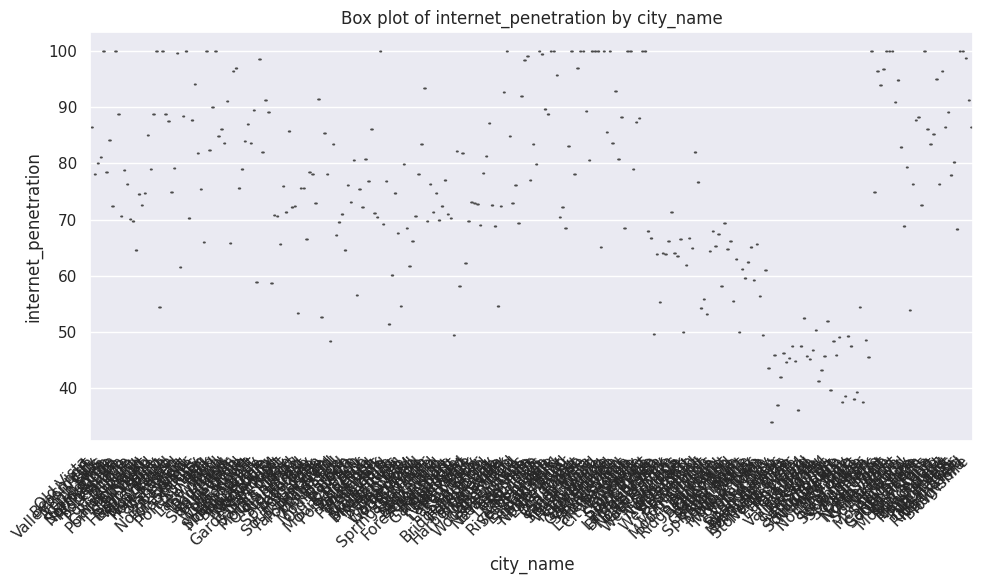

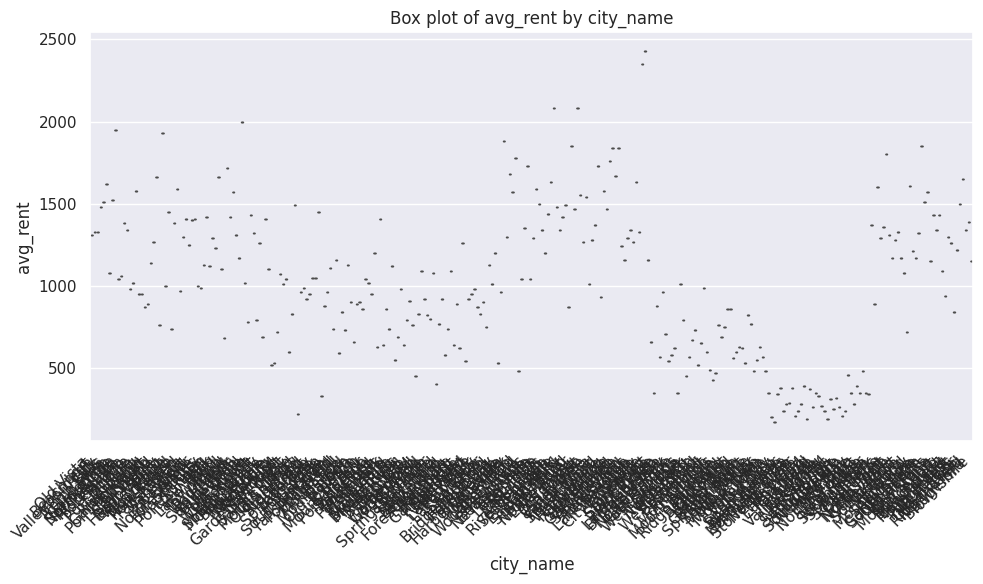

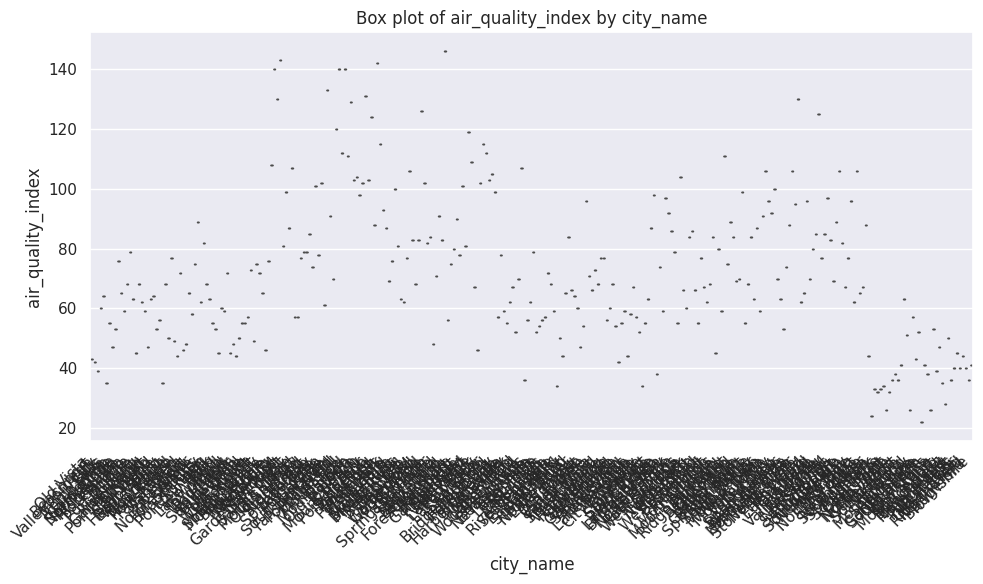

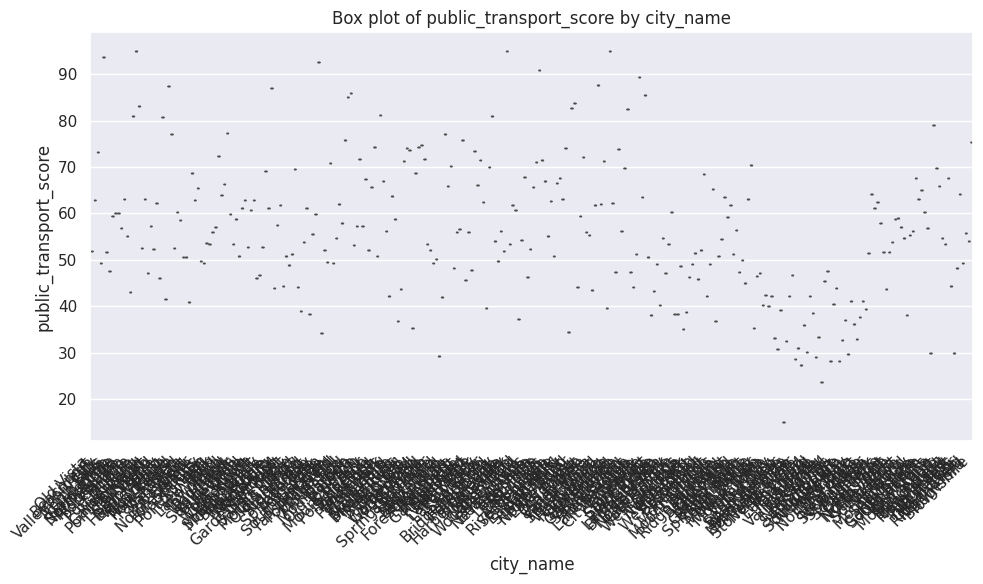

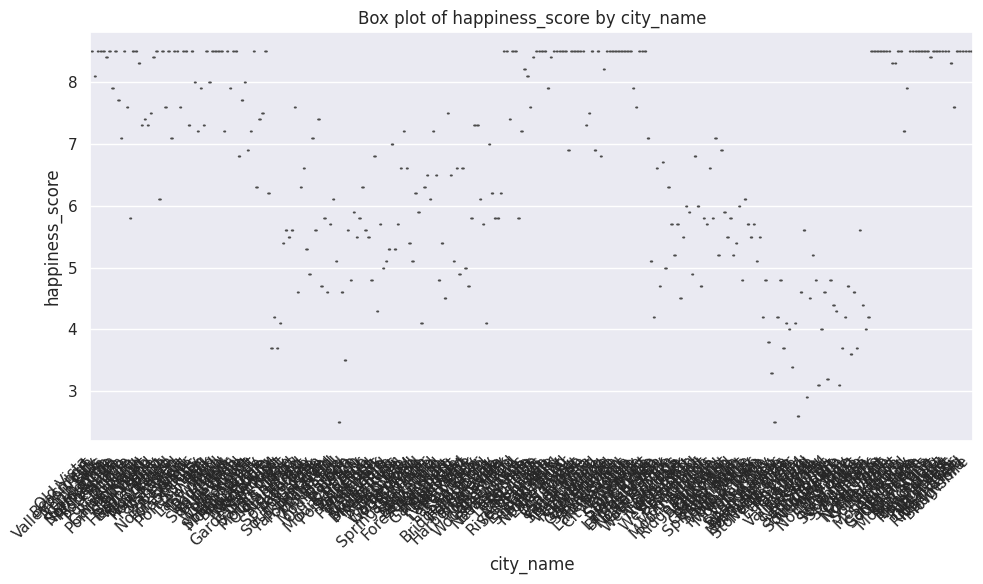

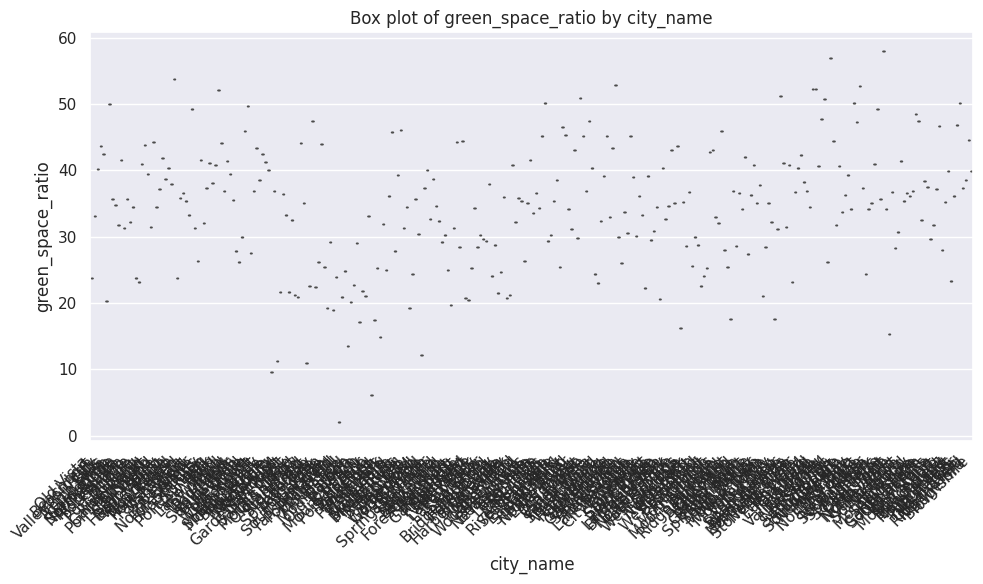

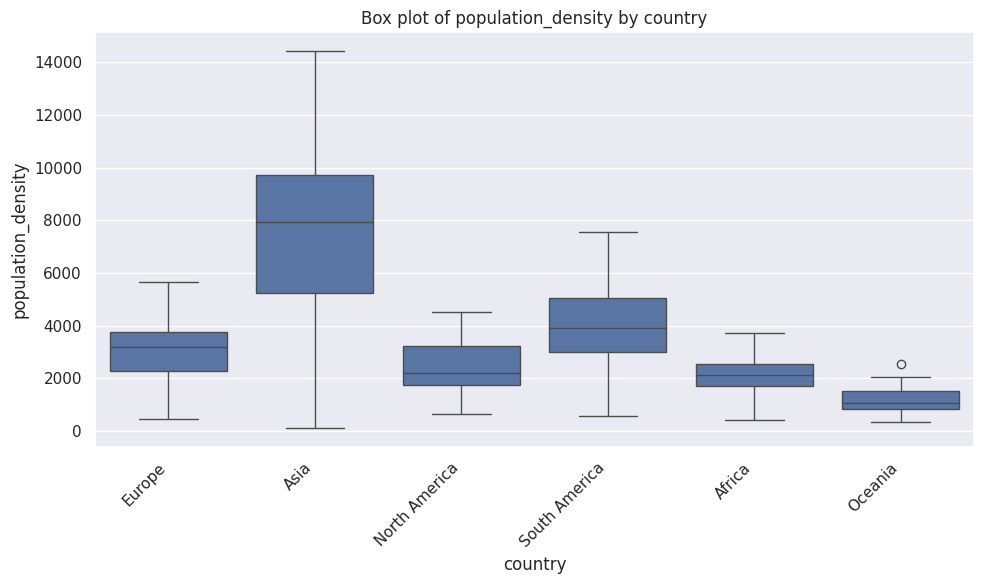

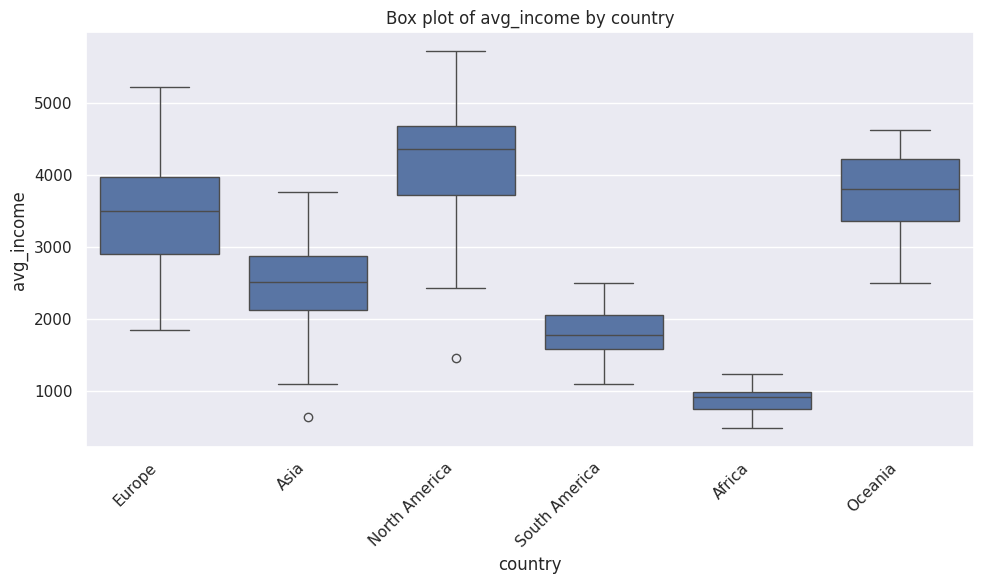

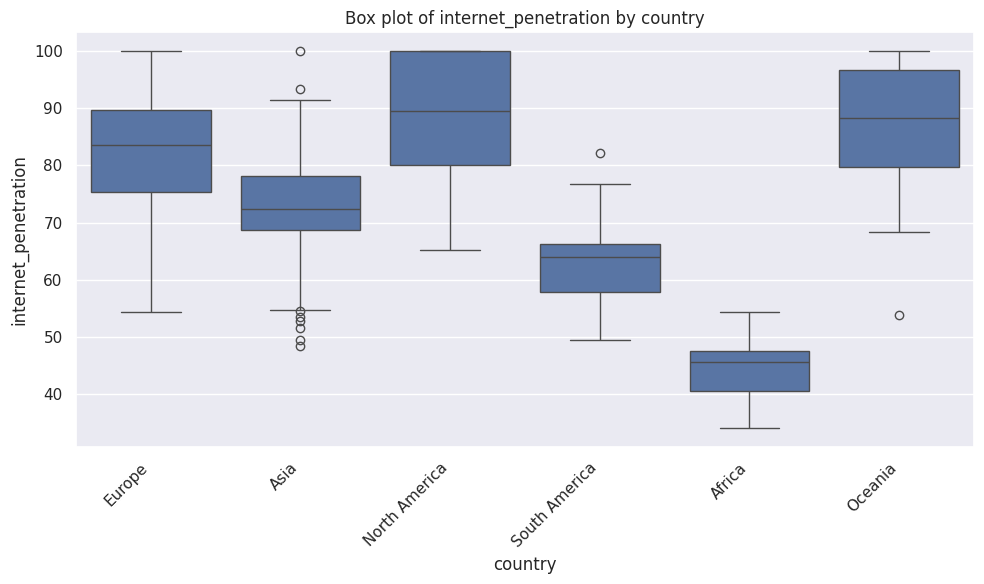

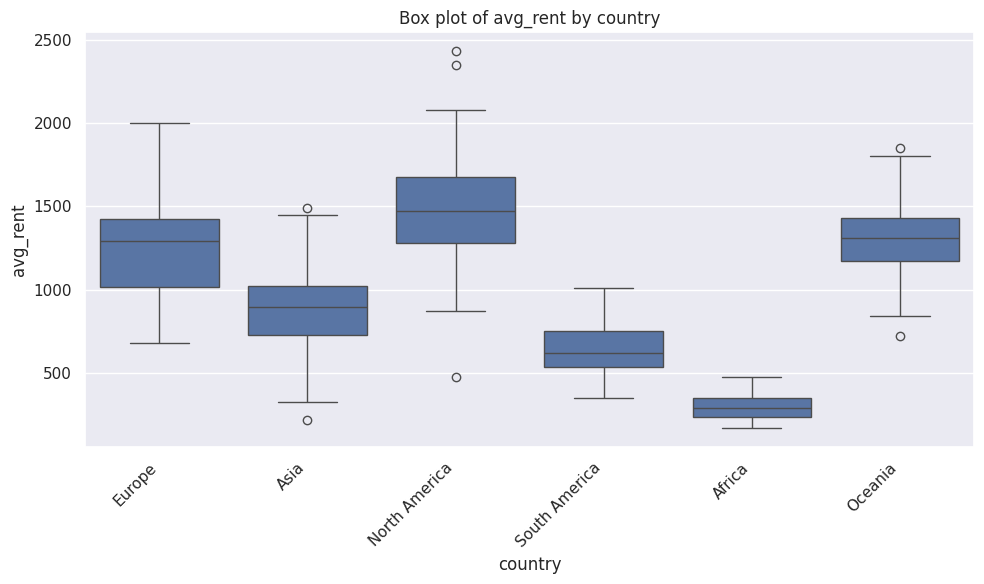

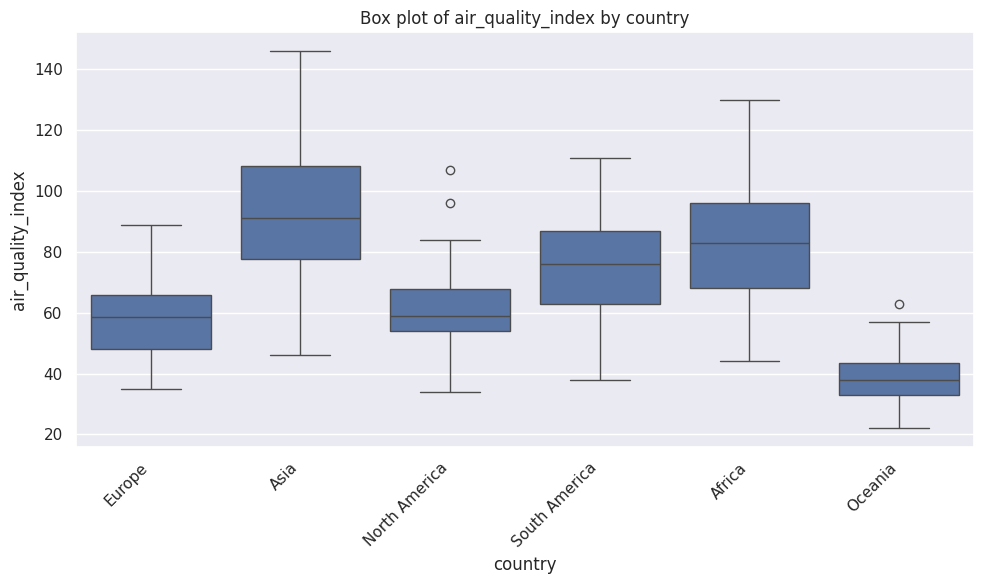

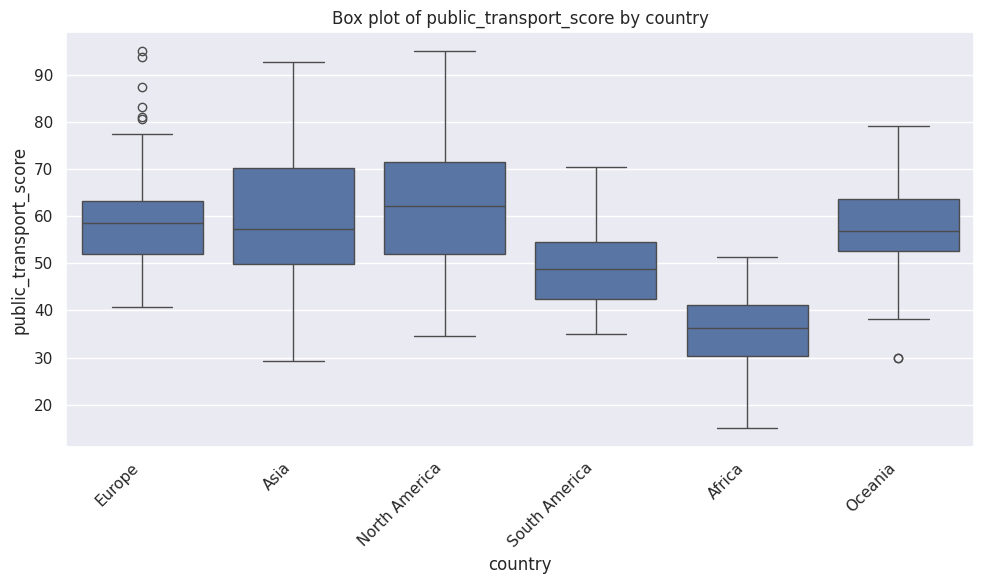

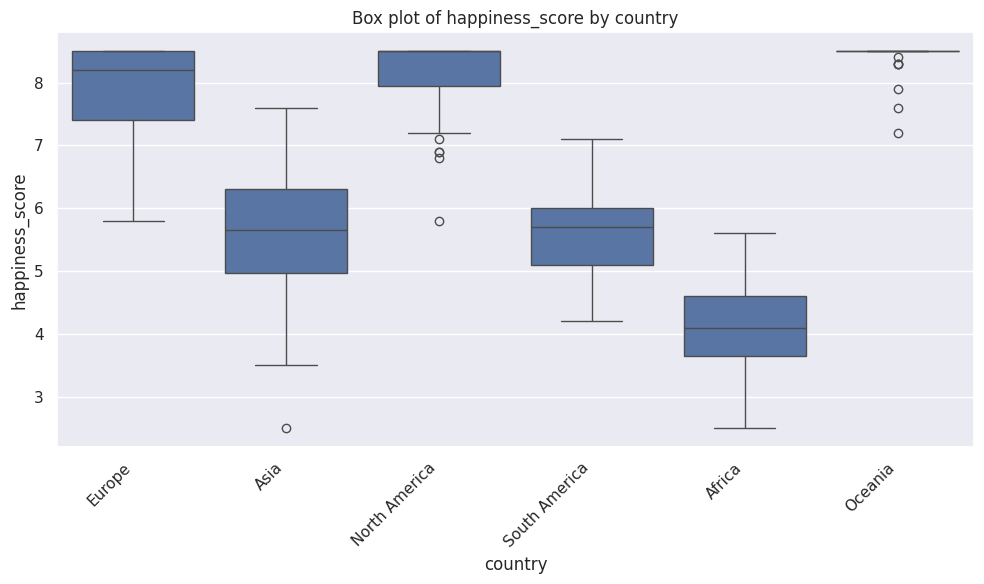

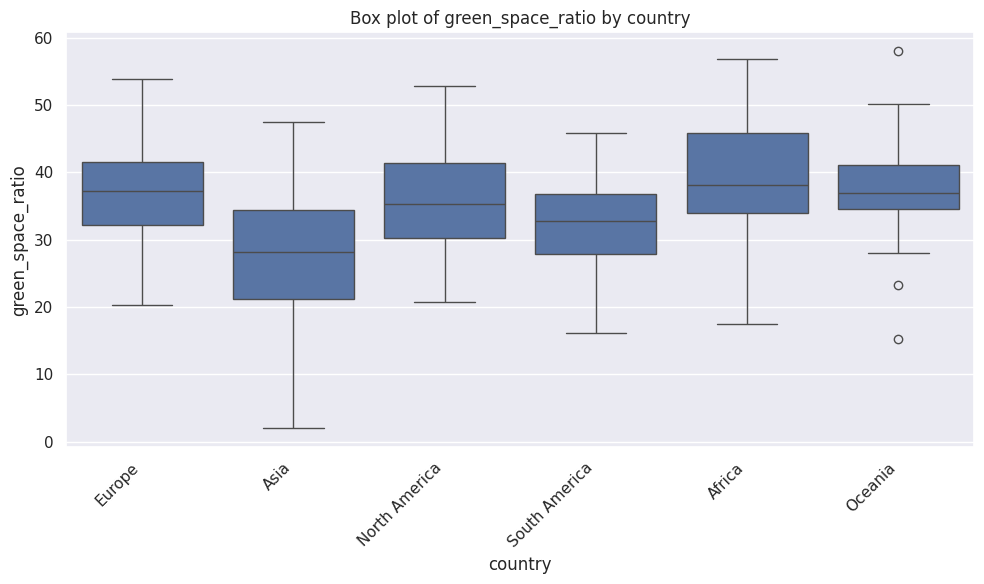

In [18]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

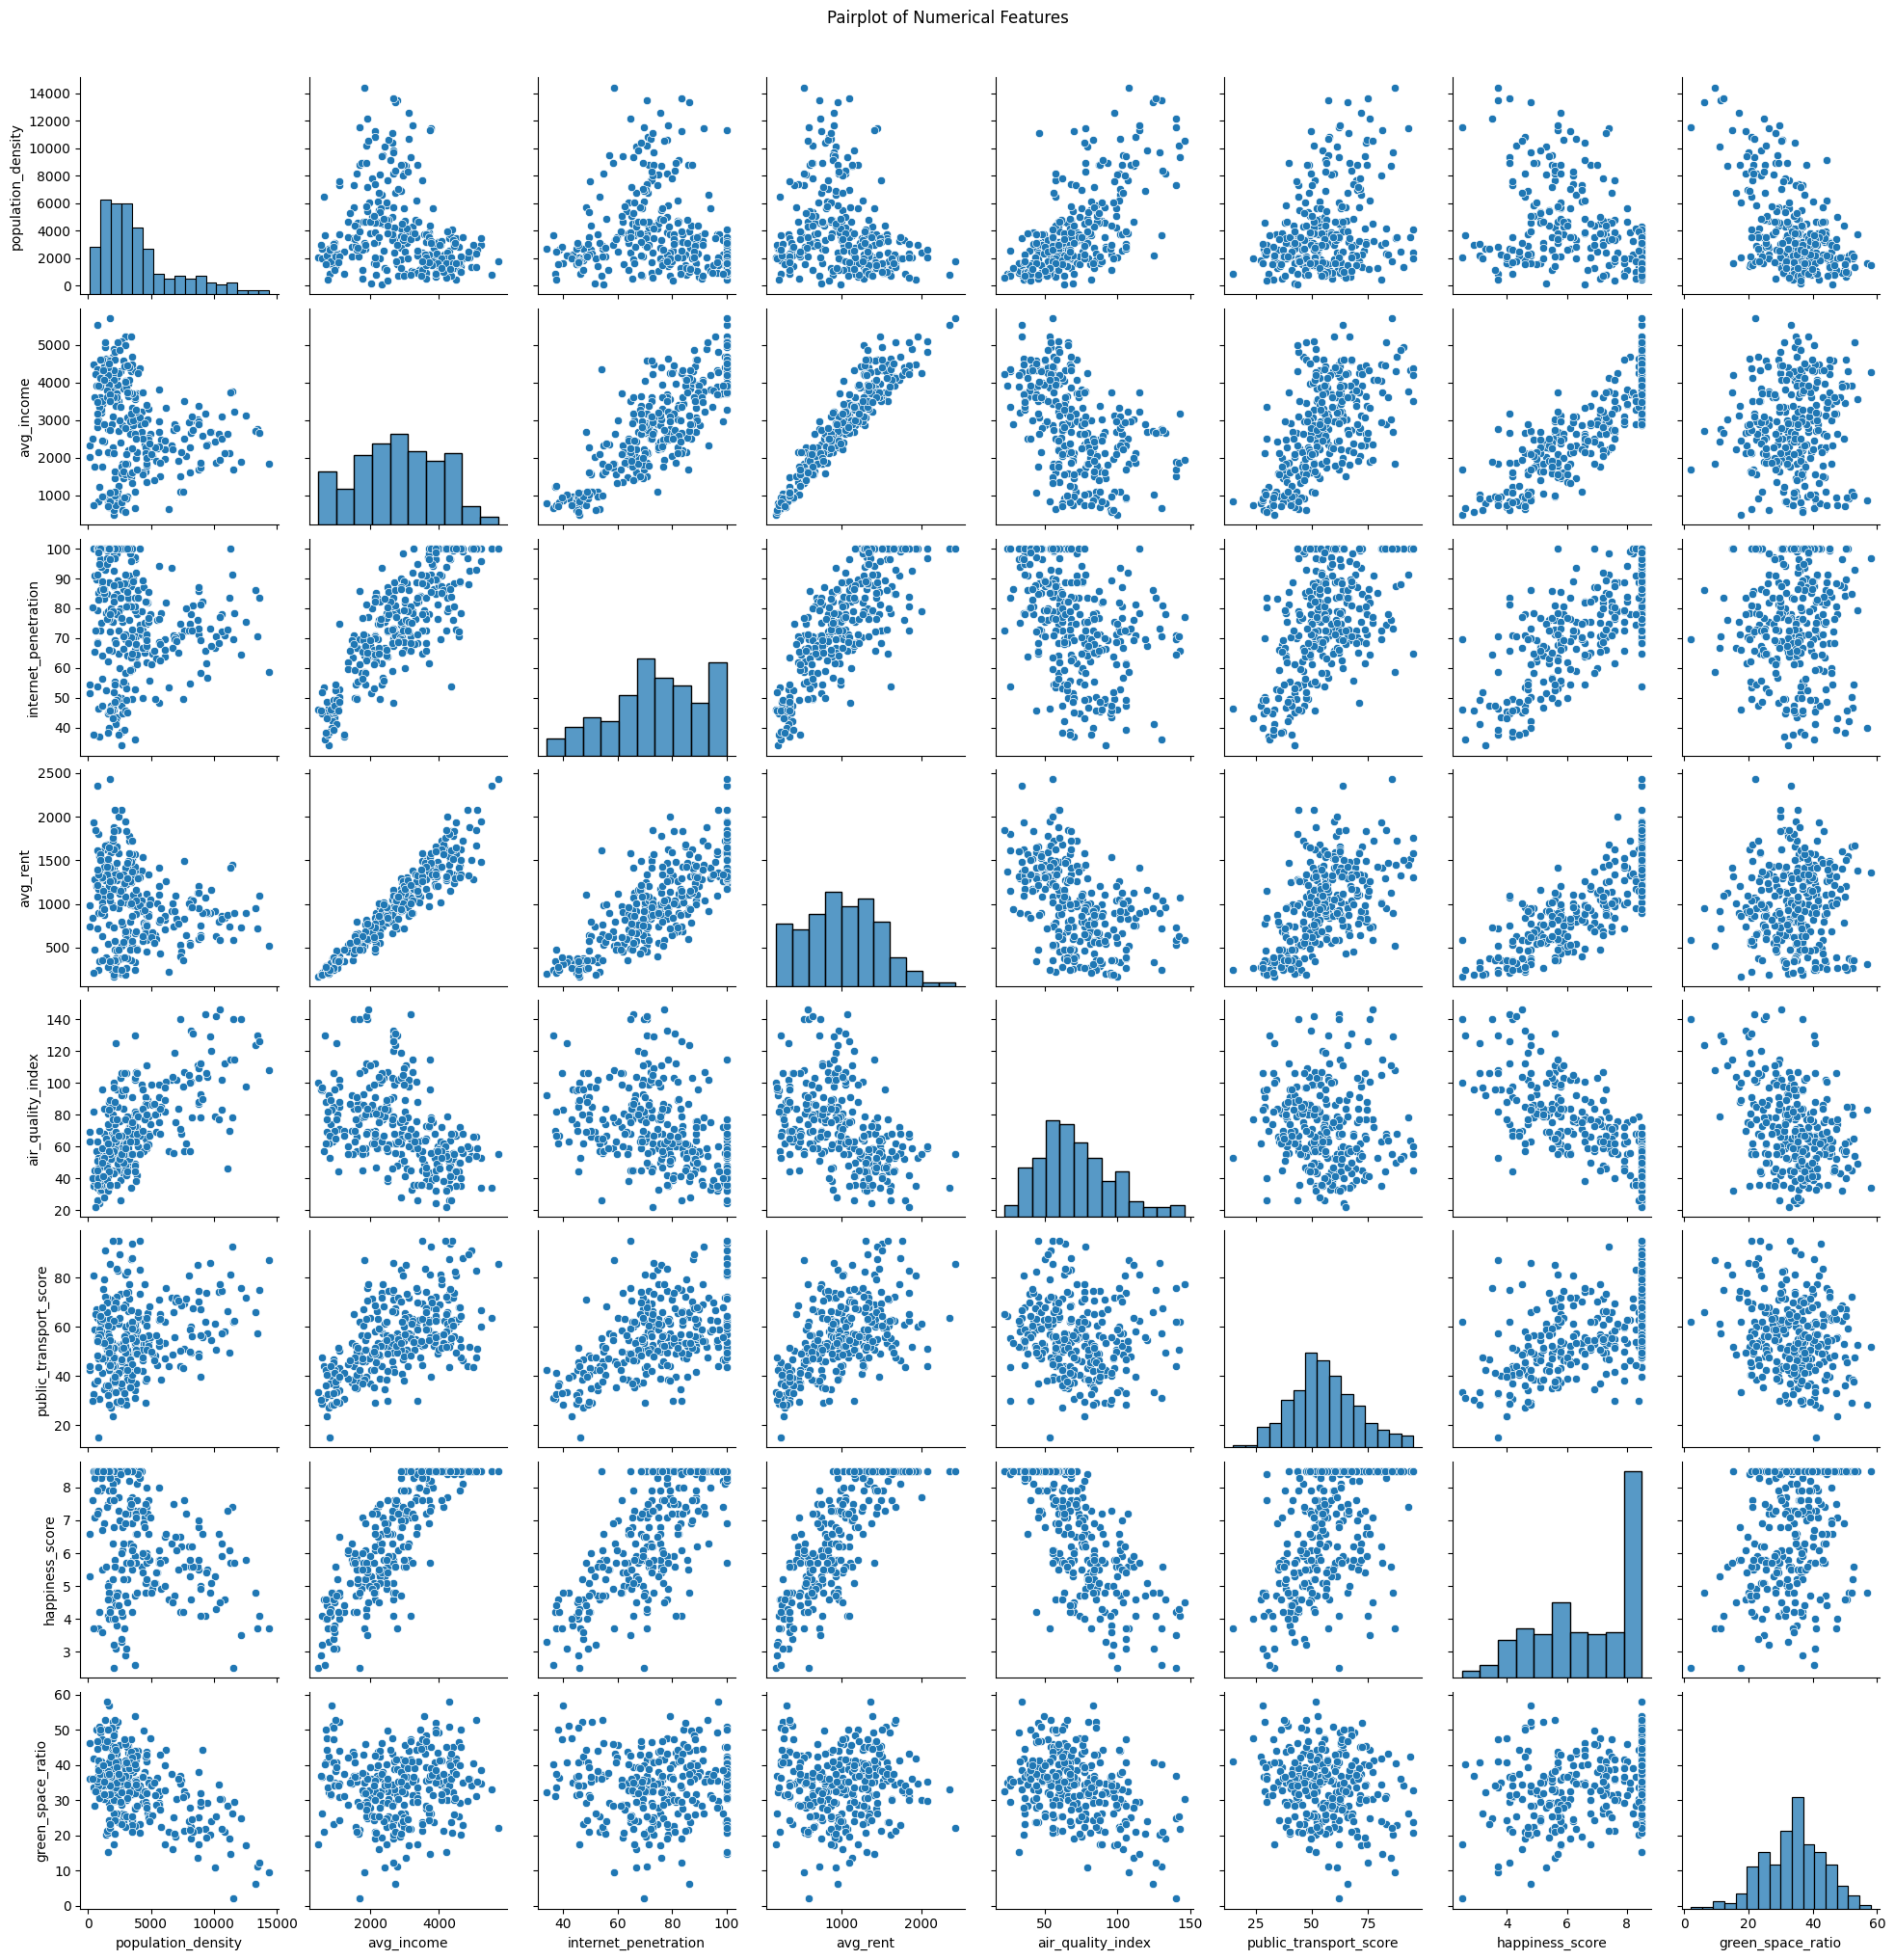

In [14]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

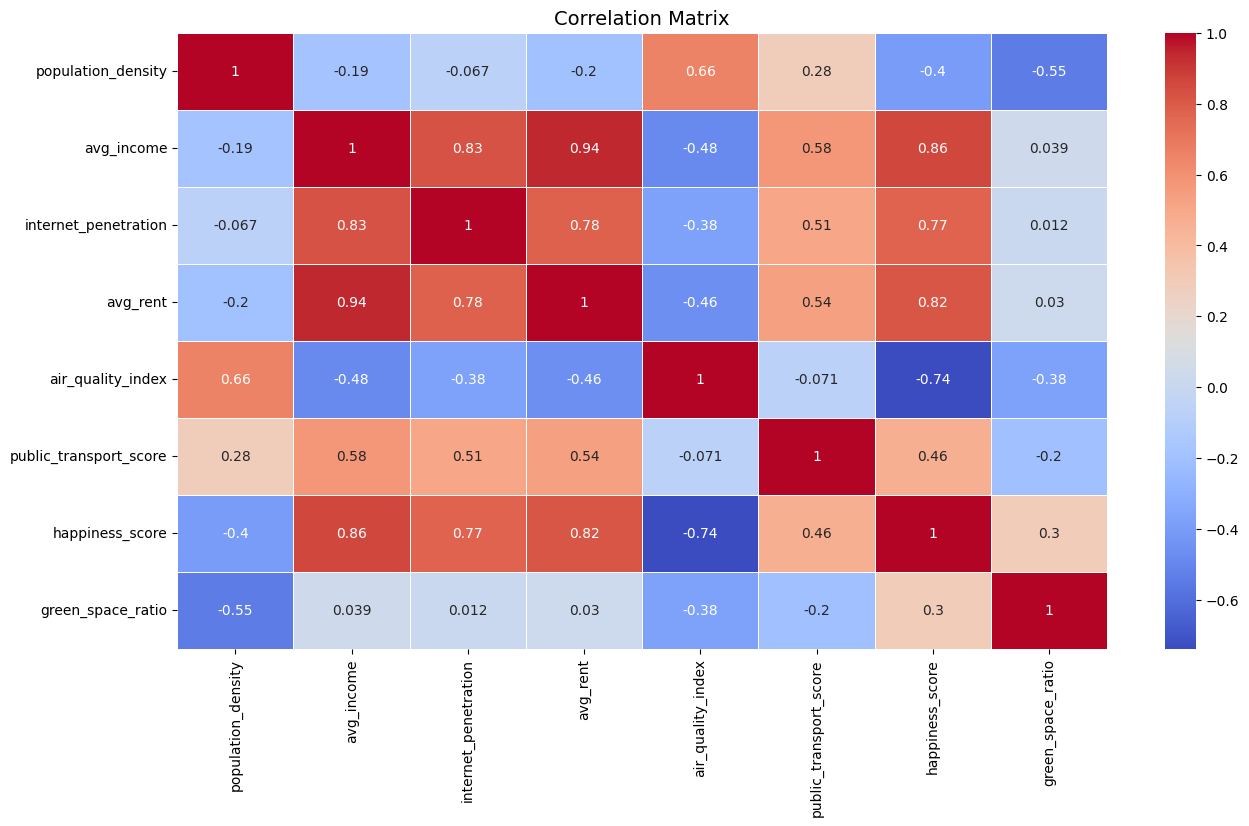

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You